# Couverture minimale dans les hubs connus (PwC & HF)

**But.** Borne basse de présence : « au moins X % du corpus est présent dans un
hub ». On part du corpus (fini) et on interroge les hubs, jamais l'inverse.
Deux hubs **rapportés séparément** :

| Hub | Source | Match |
|-----|--------|-------|
| **PwC** | archive figée (28/07/2025), join local | `arxiv_id` (titre en fallback) |
| **HF** | API live **datée** | cascade `direct` → `arxiv` → `name` (tier `name` hors borne) |

La logique de matching vit dans `src/coverage/hub_coverage.py`. La résolution
`bibkey → arxiv_id` (déjà figée) vit dans `src/coverage/s2_arxiv_resolution.py`.
Ce notebook ne fait que charger, matcher et sauvegarder le résultat.


## 0. Config & flags

In [1]:
import sys
import logging
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path().resolve().parent / "src"))

from logging_config import setup_logging
from coverage import hub_coverage as hc

setup_logging()
logger = logging.getLogger("hub_coverage")

# --- flags de lancement ---
RUN_S2_ARXIV = (
    False  # False = charge le parquet déjà résolu (défaut) ; True = relance S2/arXiv
)
RUN_PWC = True  # matching PwC (offline, instantané)
RUN_HF = True  # matching HF (API live, ~1.4k requêtes ciblées, résumable via cache)

HF_TOKEN = None  # anonyme (suffisant) ; mets un token pour réduire le rate-limit
HF_DO_NAME_SEARCH = False  # tier séparé "candidats à auditer" (hors borne)
S2_API_KEY = ""  # utilisé seulement si RUN_S2_ARXIV

## 1. Corpus de départ

Par défaut (`RUN_S2_ARXIV = False`) on charge directement le parquet enrichi :
la résolution `bibkey → arxiv_id` y est déjà figée. On ajoute juste les clés de
matching normalisées (`arxiv_norm`, `title_norm`).


In [2]:
if RUN_S2_ARXIV:
    from coverage.s2_arxiv_resolution import run_s2_arxiv_resolution

    df = run_s2_arxiv_resolution(api_key=S2_API_KEY)
else:
    df = pd.read_parquet(hc.ENRICHED_LINKS_FILE)

df["arxiv_norm"] = df["arxiv_id"].map(hc.norm_arxiv)
df["title_norm"] = df["title"].map(hc.norm_title)
print(df.shape, "| avec arxiv_id:", int(df["arxiv_norm"].notna().sum()))

(1357, 28) | avec arxiv_id: 518


## 2. Match PwC (archive figée, offline)

In [3]:
if RUN_PWC:
    df = hc.match_pwc(df)
    print(df["pwc_match_method"].value_counts().to_string())

2026-06-10 13:21:17  INFO      PwC: in_pwc=1025 (arxiv=469, title=556) | dataset=165 / 1357
pwc_match_method
title    556
arxiv    469
none     332


## 3. Match HF (API datée, cascade résumable)

`in_hf` = niveaux `direct`/`arxiv` (sûrs). Le `name search` alimente
`hf_namesearch_candidates` (hors borne). Cache disque (`hf_resolution.parquet`)
→ relançable sans tout re-requêter.


In [5]:
if RUN_HF:
    df = hc.match_hf(df, token=HF_TOKEN, do_name_search=HF_DO_NAME_SEARCH)
    print(df["hf_match_method"].value_counts().to_string())

2026-06-10 13:24:58  INFO      HF: en cache=300 | à interroger=1057 (anonyme=True)


c:\Users\samma\Documents\Programmation\UdeM\nlp-benchmark-taxonomy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-06-10 13:27:09  INFO      HF: in_hf=110 (direct=48, arxiv=62) | name seul=0 / 1357
hf_match_method
none      1247
arxiv       62
direct      48


## 4. Résultat & sauvegarde

In [6]:
# sérialise les colonnes listes pour le parquet
export = df.copy()
for c in ["pwc_datasets", "pwc_dataset_urls", "hf_namesearch_candidates"]:
    if c in export:
        export[c] = export[c].map(
            lambda v: "; ".join(map(str, v)) if isinstance(v, (list, tuple)) else None
        )

hc.OUT_DIR.mkdir(parents=True, exist_ok=True)
export.to_parquet(hc.COVERAGE_OUT_FILE, index=False)
print(len(export), "lignes ->", hc.COVERAGE_OUT_FILE)

cols = [
    c
    for c in [
        "bibkey",
        "title",
        "in_pwc",
        "pwc_match_method",
        "in_pwc_dataset",
        "in_hf",
        "hf_match_method",
        "hf_dataset_id",
    ]
    if c in df
]
df[cols].head(20)

1357 lignes -> C:\Users\samma\Documents\Programmation\UdeM\nlp-benchmark-taxonomy\data\hub_coverage\benchmark_hub_coverage.parquet


,bibkey,title,in_pwc,pwc_match_method,in_pwc_dataset,in_hf,hf_match_method,hf_dataset_id
0,-etal-2020-multi,Multi-domain Tweet Corpora for Sentiment Analy...,True,title,False,False,none,NaN
1,-etal-2022-hindimd,HindiMD: A Multi-domain Corpora for Low-resour...,True,title,False,False,none,NaN
2,abbes-etal-2020-daict,DAICT: A Dialectal Arabic Irony Corpus Extract...,True,title,False,False,none,NaN
3,abdelkadir-etal-2024-diverse,"Diverse Perspectives, Divergent Models: Cross-...",True,arxiv,False,False,none,NaN
4,abdul-mageed-etal-2018-tweet,You Tweet What You Speak: A City-Level Dataset...,True,title,False,False,none,NaN
5,abdul-mageed-etal-2020-toward,Toward Micro-Dialect Identification in Diaglos...,True,title,False,False,none,NaN
6,abercrombie-batista-navarro-2018-aye,‘Aye’ or ‘No’? Speech-level Sentiment Analysis...,True,title,False,False,none,NaN
7,abercrombie-batista-navarro-2020-parlvote,ParlVote: A Corpus for Sentiment Analysis of P...,True,title,False,False,none,NaN
8,abercrombie-etal-2019-policy,Policy Preference Detection in Parliamentary D...,True,title,False,False,none,NaN
9,abercrombie-hovy-2016-putting,Putting Sarcasm Detection into Context: The Ef...,True,title,False,False,none,NaN


## 5. Présence dans les hubs (barre empilée unique)

Une seule barre = 100 % du corpus, segmentée en **les deux** / **PwC-dataset
seul** / **HF seul** / **aucun hub**. Côté PwC on prend `in_pwc_dataset` (présence
comme *dataset*, le signal fort), pas le papier en général. Dates de snapshot
annotées (PwC figé, HF daté). Cellule autonome : relit le parquet du match.

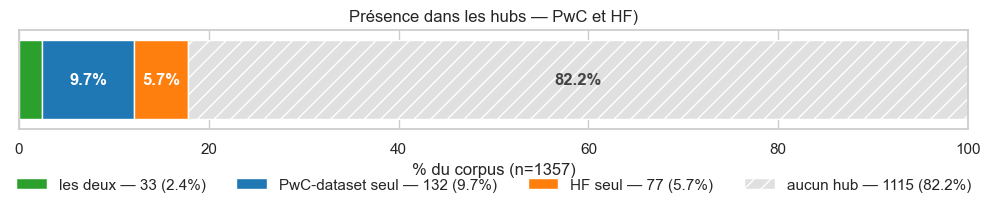

In [3]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path().resolve().parent / "src"))
from coverage import hub_coverage as hc

sns.set_theme(style="whitegrid")

# autonome : relit le résultat du match déjà sauvegardé (pas besoin de tout relancer)
df = pd.read_parquet(hc.COVERAGE_OUT_FILE)
n = len(df)
hf_date = (
    df["hf_query_date"].dropna().iloc[0]
    if df.get("hf_query_date") is not None and df["hf_query_date"].notna().any()
    else "n/a"
)
# PwC mesuré par la présence comme dataset (signal fort), pas le papier en général
pwc = df["in_pwc_dataset"].fillna(False)
hf = df["in_hf"].fillna(False)
segs = [
    ("les deux", int((pwc & hf).sum()), "#2ca02c"),
    ("PwC-dataset seul", int((pwc & ~hf).sum()), "#1f77b4"),
    ("HF seul", int((~pwc & hf).sum()), "#ff7f0e"),
    ("aucun hub", int((~pwc & ~hf).sum()), "#e0e0e0"),
]

fig, ax = plt.subplots(figsize=(11, 2.6))
left = 0.0
for label, count, color in segs:
    pct = count / n * 100
    ax.barh(
        0,
        pct,
        left=left,
        color=color,
        edgecolor="white",
        hatch="//" if label == "aucun hub" else None,
        label=f"{label} — {count} ({pct:.1f}%)",
    )
    if pct >= 5:
        ax.text(
            left + pct / 2,
            0,
            f"{pct:.1f}%",
            ha="center",
            va="center",
            color="#444" if label == "aucun hub" else "white",
            fontweight="bold",
        )
    left += pct

ax.set_xlim(0, 100)
ax.set_ylim(-0.5, 0.5)
ax.set_yticks([])
ax.set_xlabel(f"% du corpus (n={n})")
ax.set_title("Présence dans les hubs — PwC et HF)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=4, frameon=False)
plt.tight_layout()
plt.savefig(hc.OUT_DIR / "presence_lower_bound.png", dpi=150, bbox_inches="tight")
plt.show()